[*********************100%***********************]  1 of 1 completed


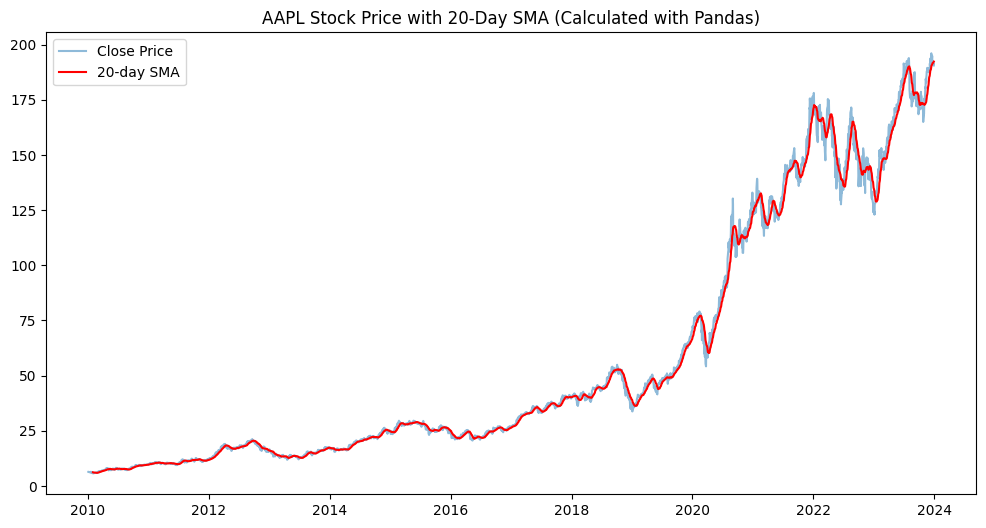

✅ Task 2 initial progress complete using Pandas!


In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Download data (Using a single stock like AAPL for the example)
stock_data = yf.download("AAPL", start="2010-01-01", end="2024-01-01")

# 2. Basic Cleaning
stock_data.dropna(inplace=True)

# 3. Compute ONE technical indicator using Pandas (Instead of TA-Lib)
# Simple Moving Average (SMA)
stock_data['SMA_20'] = stock_data['Close'].rolling(window=20).mean()

# 4. Simple Plot
plt.figure(figsize=(12,6))
plt.plot(stock_data['Close'], label='Close Price', alpha=0.5)
plt.plot(stock_data['SMA_20'], label='20-day SMA', color='red')
plt.title('AAPL Stock Price with 20-Day SMA (Calculated with Pandas)')
plt.legend()
plt.savefig('../data/raw/stock_initial_analysis.png', dpi=150)
plt.show()

print("✅ Task 2 initial progress complete using Pandas!")

In [3]:
# Add more Moving Averages
stock_data['SMA_50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['SMA_200'] = stock_data['Close'].rolling(window=200).mean()

# Exponential Moving Average
stock_data['EMA_20'] = stock_data['Close'].ewm(span=20, adjust=False).mean()

print("✅ Moving averages computed!")
stock_data[['Close', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_20']].tail()

✅ Moving averages computed!


Price,Close,SMA_20,SMA_50,SMA_200,EMA_20
Ticker,AAPL,,,,
Date,,,,,
2023-12-22,191.609467,191.677265,183.401249,176.443945,191.331200
2023-12-26,191.065109,191.838589,183.686987,176.667374,191.305858
2023-12-27,191.164078,191.974675,183.977274,176.881588,191.292355
2023-12-28,191.589691,192.183012,184.307109,177.087481,191.320673
2023-12-29,190.550461,192.310686,184.642057,177.286207,191.247319


In [4]:
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

stock_data['RSI'] = compute_rsi(stock_data['Close'])

print("✅ RSI computed!")
print(f"Latest RSI value: {stock_data['RSI'].iloc[-1]:.2f}")
stock_data['RSI'].tail()

✅ RSI computed!
Latest RSI value: 40.19


Date
2023-12-22    59.246117
2023-12-26    49.031839
2023-12-27    52.291398
2023-12-28    47.920388
2023-12-29    40.185121
Name: RSI, dtype: float64

In [5]:
def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

stock_data['MACD'], stock_data['MACD_signal'], stock_data['MACD_hist'] = compute_macd(stock_data['Close'])

print("✅ MACD computed!")
stock_data[['MACD', 'MACD_signal', 'MACD_hist']].tail()

✅ MACD computed!


Price,MACD,MACD_signal,MACD_hist
Ticker,,,
Date,,,
2023-12-22,2.630678,3.232231,-0.601553
2023-12-26,2.302594,3.046304,-0.743709
2023-12-27,2.027203,2.842484,-0.815281
2023-12-28,1.822291,2.638445,-0.816154
2023-12-29,1.558078,2.422372,-0.864293


In [6]:
# Daily percentage return
stock_data['Daily_Return'] = stock_data['Close'].pct_change() * 100

print("✅ Daily returns computed!")
print(f"\nAverage daily return: {stock_data['Daily_Return'].mean():.4f}%")
print(f"Max daily gain: {stock_data['Daily_Return'].max():.4f}%")
print(f"Max daily loss: {stock_data['Daily_Return'].min():.4f}%")
stock_data['Daily_Return'].describe()

✅ Daily returns computed!

Average daily return: 0.1122%
Max daily gain: 11.9808%
Max daily loss: -12.8647%


count    3521.000000
mean        0.112161
std         1.776435
min       -12.864660
25%        -0.751555
50%         0.095073
75%         1.047255
max        11.980786
Name: Daily_Return, dtype: float64

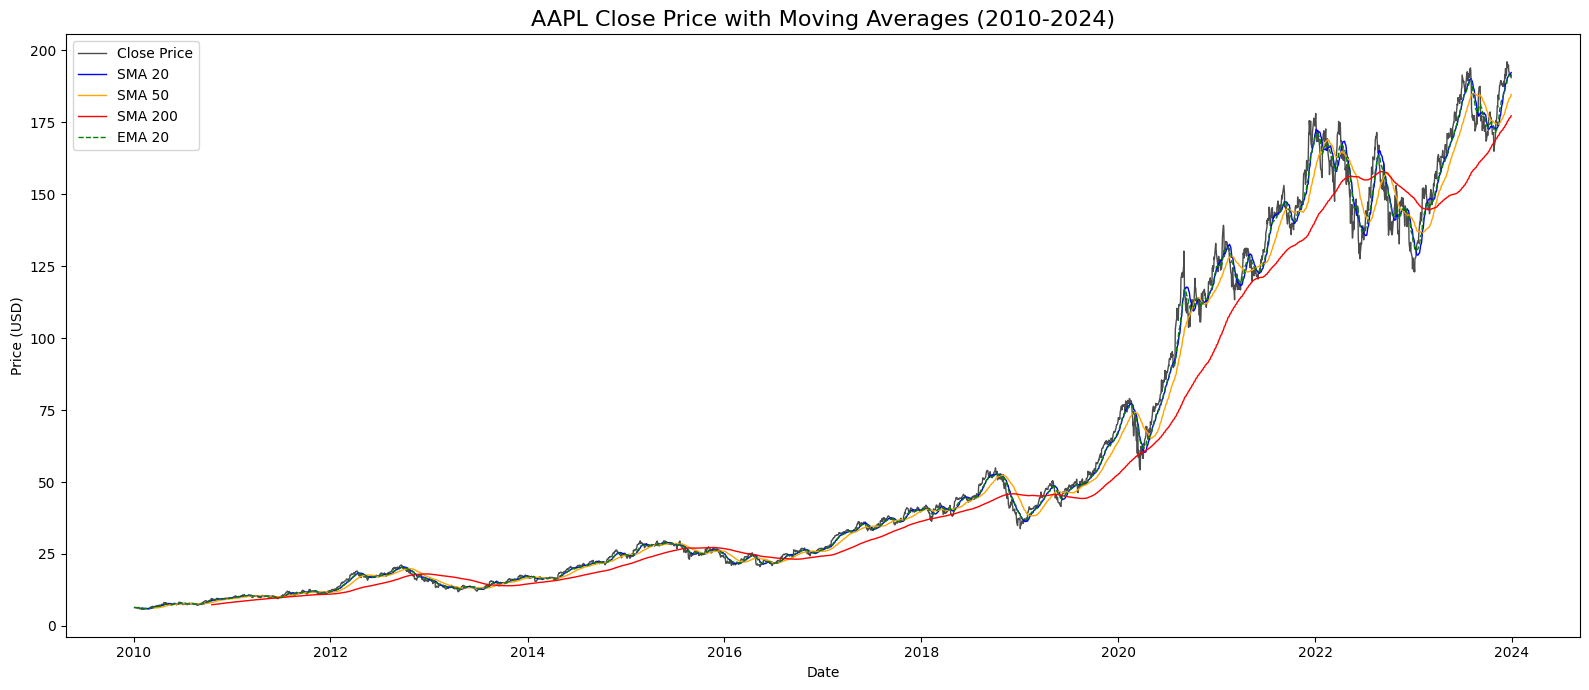

✅ Plot 1 saved!


In [7]:
plt.figure(figsize=(16, 7))
plt.plot(stock_data['Close'], label='Close Price', color='black', linewidth=1, alpha=0.7)
plt.plot(stock_data['SMA_20'], label='SMA 20', color='blue', linewidth=1)
plt.plot(stock_data['SMA_50'], label='SMA 50', color='orange', linewidth=1)
plt.plot(stock_data['SMA_200'], label='SMA 200', color='red', linewidth=1)
plt.plot(stock_data['EMA_20'], label='EMA 20', color='green', linewidth=1, linestyle='--')

plt.title('AAPL Close Price with Moving Averages (2010-2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/raw/price_with_moving_averages.png', dpi=150)
plt.show()
print("✅ Plot 1 saved!")

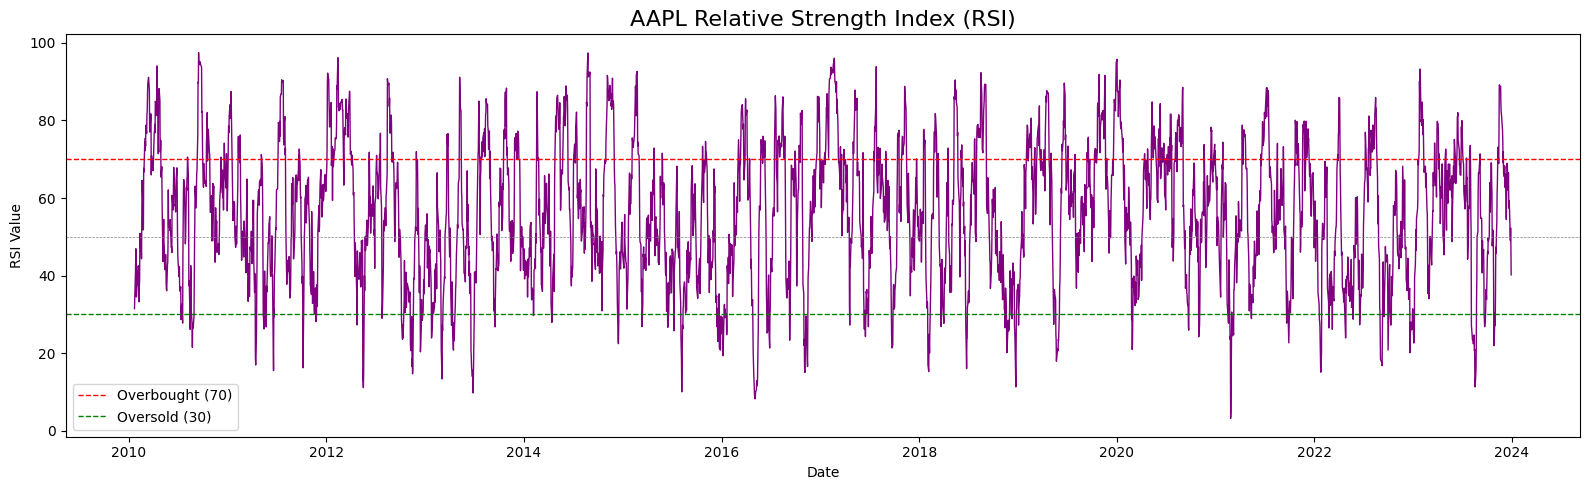

✅ RSI plot saved!


In [8]:
plt.figure(figsize=(16, 5))
plt.plot(stock_data['RSI'], color='purple', linewidth=1)
plt.axhline(70, color='red', linestyle='--', linewidth=1, label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
plt.axhline(50, color='grey', linestyle='--', linewidth=0.5)

plt.title('AAPL Relative Strength Index (RSI)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('RSI Value')
plt.legend()
plt.tight_layout()
plt.savefig('../data/raw/rsi_plot.png', dpi=150)
plt.show()
print("✅ RSI plot saved!")

C:\Users\Rinatoh computer\AppData\Local\Temp\ipykernel_10900\534159323.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('../data/raw/macd_plot.png', dpi=150)


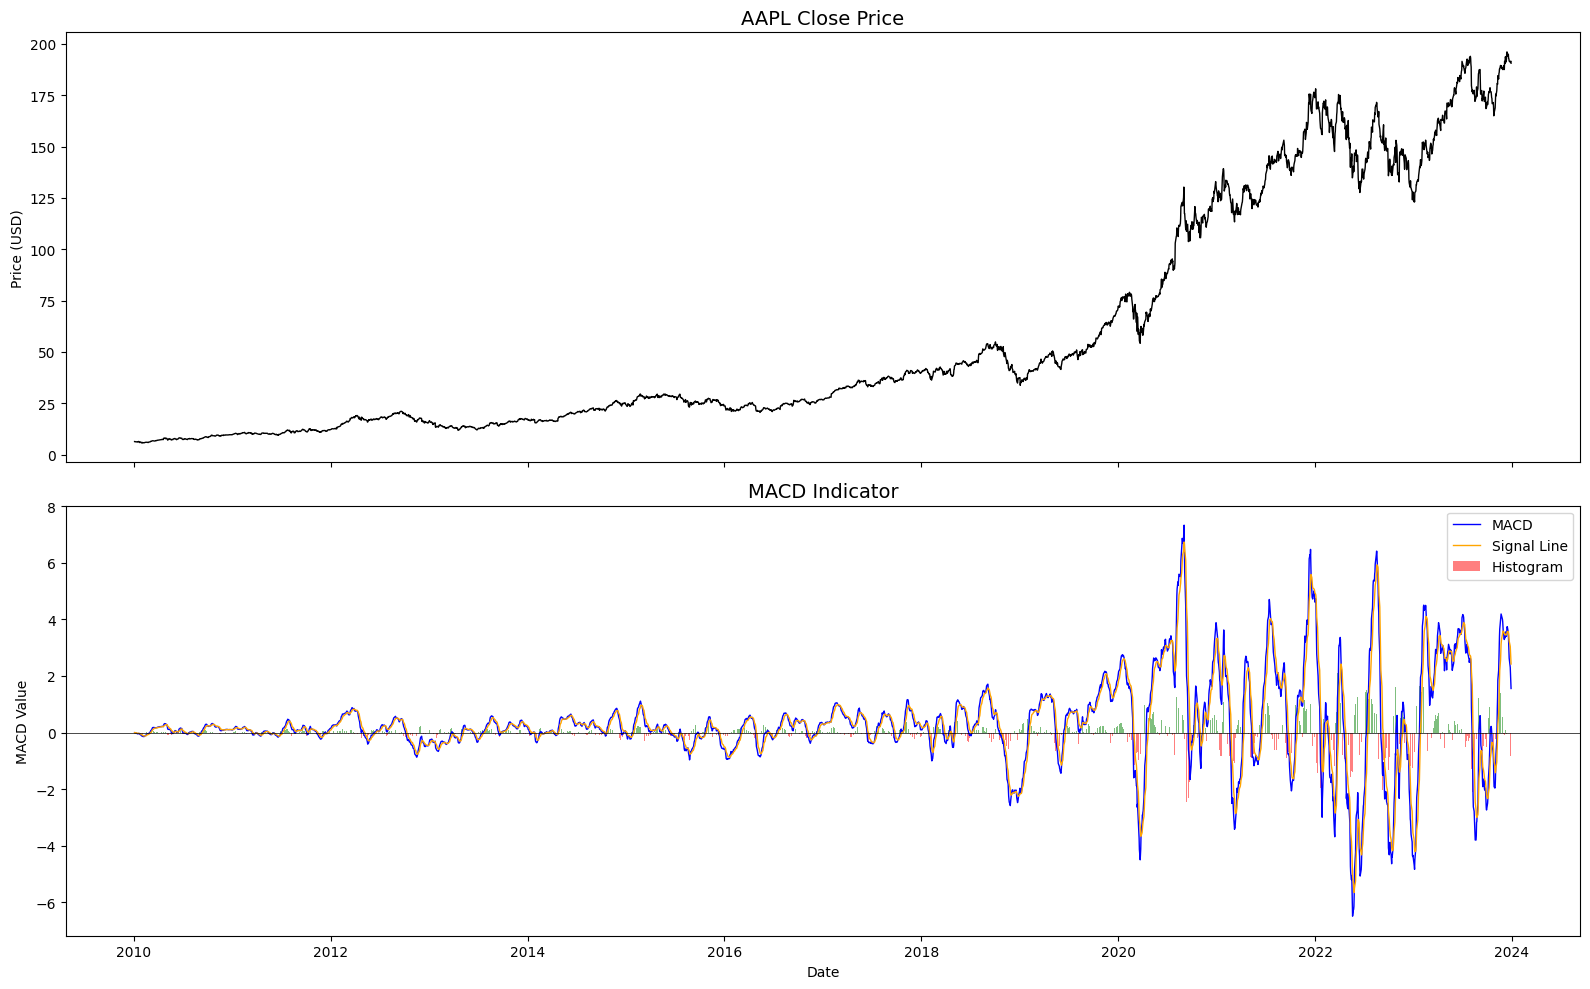

✅ MACD plot saved!


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Price on top
ax1.plot(stock_data['Close'], color='black', linewidth=1)
ax1.set_title('AAPL Close Price', fontsize=14)
ax1.set_ylabel('Price (USD)')

# MACD on bottom
ax2.plot(stock_data['MACD'], label='MACD', color='blue', linewidth=1)
ax2.plot(stock_data['MACD_signal'], label='Signal Line', color='orange', linewidth=1)
ax2.bar(stock_data.index, stock_data['MACD_hist'], 
        color=stock_data['MACD_hist'].apply(lambda x: 'green' if x > 0 else 'red'),
        alpha=0.5, label='Histogram')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('MACD Indicator', fontsize=14)
ax2.set_ylabel('MACD Value')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.savefig('../data/raw/macd_plot.png', dpi=150)
plt.show()
print("✅ MACD plot saved!")

In [10]:
print("=== TASK 2 SUMMARY ===")
print(f"\nStock analyzed: AAPL")
print(f"Date range: {stock_data.index[0].date()} to {stock_data.index[-1].date()}")
print(f"Total trading days: {len(stock_data)}")
print(f"\nPrice Statistics:")
print(stock_data['Close'].describe())
print(f"\nIndicators computed:")
print("  ✅ SMA (20, 50, 200 day)")
print("  ✅ EMA (20 day)")
print("  ✅ RSI (14 day)")
print("  ✅ MACD (12/26/9)")
print("  ✅ Daily Returns")

# Save cleaned stock data for Task 3
stock_data.to_csv('../data/raw/aapl_with_indicators.csv')
print("\n✅ Stock data with indicators saved for Task 3!")

=== TASK 2 SUMMARY ===

Stock analyzed: AAPL
Date range: 2010-01-04 to 2023-12-29
Total trading days: 3522

Price Statistics:
Ticker         AAPL
count   3522.000000
mean      57.324835
std       55.279181
min        5.754397
25%       16.875343
50%       28.913476
75%       88.391001
max      196.073074

Indicators computed:
  ✅ SMA (20, 50, 200 day)
  ✅ EMA (20 day)
  ✅ RSI (14 day)
  ✅ MACD (12/26/9)
  ✅ Daily Returns

✅ Stock data with indicators saved for Task 3!
